## Compute Statistics for state


In [1]:
state="NJ"

In [2]:
import pandas as pd
import numpy as np
import sklearn as sk

In [3]:
%%time
%run lib/startup.py S

sc_type= S
10.41.226.219
namespace= grader-cse255-01
driver_host= 10.41.226.219


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


25/04/30 18:18:38 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
sparkContext= <SparkContext master=spark://spark-master-0.spark-headless.grader-cse255-01.svc.cluster.local:7077 appName=myapp>



/opt/bitnami/spark/python/pyspark/sql/context.py:112: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


version of ipwidgets= 8.1.6
parquet_root= /home/grader-cse255-01/public/Data/weather


measurements is a Dataframe (and table) with 12720632 records


stations is a Dataframe (and table) with 119503 records


weather is a Dataframe (and table) which is a join of measurements and stations with 12720632 records
CPU times: user 693 ms, sys: 185 ms, total: 878 ms
Wall time: 1min 23s


In [4]:
import warnings  # Suppress Warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2 

sc.setLogLevel("ERROR")

_figsize=(10,7)

In [5]:
ms=['TMAX', 'SNOW', 'SNWD', 'TMIN', 'PRCP', 'TOBS']
cms='or\n'.join(['Measurement="%s" '%(m) for m in ms])

##  read all data for state
Query="""
SELECT *
FROM weather
WHERE state="%s" and 
(%s)
"""%(state,cms)
print(Query)


SELECT *
FROM weather
WHERE state="NJ" and 
(Measurement="TMAX" or
Measurement="SNOW" or
Measurement="SNWD" or
Measurement="TMIN" or
Measurement="PRCP" or
Measurement="TOBS" )



In [6]:
%%time
weather_df=sqlContext.sql(Query)
print('number of rows in result=',weather_df.cache().count())
weather_df.show(2)

number of rows in result= 45361
+-----------+-----------+----+--------------------+--------+---------+---------+----------+-------------------+-----+-------------+
|    Station|Measurement|Year|              Values|latitude|longitude|elevation|dist2coast|               name|state|      country|
+-----------+-----------+----+--------------------+--------+---------+---------+----------+-------------------+-----+-------------+
|US1NJAT0046|       PRCP|2022|[17 00 5E 00 4F 0...|  39.457| -74.5087|     16.5|4.12890625|GALLOWAY TWP 2.9 SW|   NJ|United States|
|US1NJAT0046|       SNOW|2022|[00 00 00 00 17 0...|  39.457| -74.5087|     16.5|4.12890625|GALLOWAY TWP 2.9 SW|   NJ|United States|
+-----------+-----------+----+--------------------+--------+---------+---------+----------+-------------------+-----+-------------+
only showing top 2 rows

CPU times: user 41.1 ms, sys: 12.3 ms, total: 53.4 ms
Wall time: 33.5 s


In [7]:
1+1

2

### read or compute statistics information for state.

In [8]:
%%time
import os.path
from pickle import dump,load

pkl_filename=parquet_root+'/weather-statistics/'+state+'-'+','.join(ms)+'.pkl'
print(pkl_filename)
!ls $pkl_filename

/home/grader-cse255-01/public/Data/weather/weather-statistics/NJ-TMAX,SNOW,SNWD,TMIN,PRCP,TOBS.pkl
ls: cannot access '/home/grader-cse255-01/public/Data/weather/weather-statistics/NJ-TMAX,SNOW,SNWD,TMIN,PRCP,TOBS.pkl': No such file or directory
CPU times: user 0 ns, sys: 19.4 ms, total: 19.4 ms
Wall time: 404 ms


In [10]:
from lib.computeStatistics import computeStatistics

In [11]:
if os.path.isfile(pkl_filename):   
    print('precomputed statistics file exists')
    with open(pkl_filename,'br') as pkl_file:
        STAT=load(pkl_file)
else:
    print('computing statistics')
    STAT=computeStatistics(sqlContext,weather_df,measurements=ms)
    try:
        with open(pkl_filename,'bw') as pkl_file:
            dump(STAT,pkl_file)
    except:
        print(f"Could not save {pkl_file}")

STAT.keys()

computing statistics
computestatistics loading


TMAX : shape of mdf is  5333


time for TMAX is 53.10596585273743


SNOW : shape of mdf is  10618


time for SNOW is 18.102709531784058
SNWD : shape of mdf is  8800


time for SNWD is 18.004054069519043
TMIN : shape of mdf is  5368


time for TMIN is 29.398682355880737
PRCP : shape of mdf is  11243


time for PRCP is 53.10008883476257
TOBS : shape of mdf is  3999


time for TOBS is 32.19792675971985


dict_keys(['TMAX', 'SNOW', 'SNWD', 'TMIN', 'PRCP', 'TOBS'])

In [12]:
from lib.computeStatistics import STAT_Descriptions

In [13]:
print("   Name  \t                 Description             \t  Size")
print("-"*80)
print('\n'.join(["%10s\t%40s\t%s"%(s[0],s[1],str(s[2])) for s in STAT_Descriptions]))

   Name  	                 Description             	  Size
--------------------------------------------------------------------------------
     UnDef	      sample of number of undefs per row	vector whose length varies between measurements
        NE	         count of defined values per day	(366,)
SortedVals	                        Sample of values	vector whose length varies between measurements
      mean	                              mean value	()
       std	                                     std	()
    low100	                               bottom 1%	()
   high100	                                  top 1%	()
   low1000	                             bottom 0.1%	()
  high1000	                                top 0.1%	()
         E	                   Sum of values per day	(366,)
      Mean	                                    E/NE	(366,)
         O	                   Sum of outer products	(366, 366)
        NO	               counts for outer products	(366, 366)
       Cov	                

### print statistics 

In [14]:
import numpy
S=STAT['SNOW']
for key in ['mean', 'std', 'low100', 'high100']:
    element=S[key]
    print(key,'=',end='')
    if type(element)==numpy.float64 or type(element)==numpy.float16:
        print('%6.2f'%element)
    elif type(element)==numpy.ndarray:
        print (element)
    else:
        print('unidentified type=',type(element))

mean =  2.07
std = 18.19
low100 =  0.00
high100 = 36.00


In [15]:
from matplotlib.pylab import *
measurement='SNOW'
Sobs=STAT[measurement]['SortedVals']


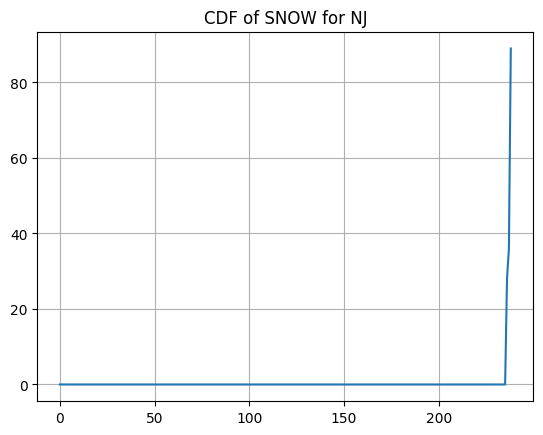

In [16]:
plot(Sobs)
title('CDF of '+measurement+" for "+state)
grid()

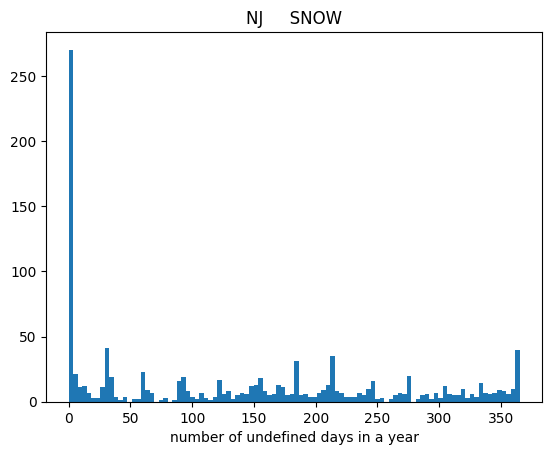

In [17]:
## distribution of undefined elements in yearly measurements.
hist(S['UnDef'],bins=100);
xlabel('number of undefined days in a year');
title(state+'     '+measurement);

In [18]:
%%time
## Find the number of measurements of each of the types in the state

Query="""
select Measurement,count(Measurement) as count
from weather
WHERE state='%s'
GROUP BY Measurement
ORDER BY count DESC
"""%state
sqlContext.sql(Query).show(15)

+-----------+-----+
|Measurement|count|
+-----------+-----+
|       PRCP|11243|
|       SNOW|10618|
|       SNWD| 8800|
|       TMIN| 5368|
|       TMAX| 5333|
|       TOBS| 3999|
|       MDPR| 3342|
|       DAPR| 3319|
|       WT03| 2856|
|       WT01| 2409|
|       WT04| 2120|
|       WESF| 2060|
|       WESD| 1957|
|       WT06| 1211|
|       WT11| 1181|
+-----------+-----+
only showing top 15 rows

CPU times: user 19.5 ms, sys: 8.57 ms, total: 28 ms
Wall time: 6.33 s


In [19]:
sc.stop()